# **Projet 3 - Prédiction de la consommation énergétique des bâtiments de Seattle**

 * Prédire la consommation énergétique des bâtiments non résidentiels de Seattle à partir de leurs caractéristiques structurelles.
 * Réaliser une analyse exploratoire afin d'identifier les principales tendances et anomalies des données.
 * Comparer plusieurs modèles de régression supervisée pour sélectionner le plus performant.
 * Identifier les variables ayant le plus d'influence sur la consommation énergétique.*
 

## **Contexte** 

* La ville de Seattle souhaite atteindre la neutralité carbone d'ici 2050.
* Les relevés énergétiques des bâtiments sont coûteux à réaliser et ne sont pas disponibles pour l'ensemble du parc immobilier.
* L'objectif est d'utiliser les données collectées en 2016 afin d'estimer la consommation énergétique des bâtiments non destinés à l’habitation.

## **Objectif** 
Prédire la consommation énergétique (ou les émissions) des bâtiments non résidentiels afin d'aider la ville de Seattle à atteindre la neutralité carbone en 2050.

## **Objectfs Data** 
- **Comprendre le jeu de données :** analyser la structure, les types de variables, les valeurs manquantes et la qualité des données.
- **Nettoyer et préparer les données :** sélectionner les bâtiments non résidentiels, traiter les incohérences et préparer les variables pour la modélisation.
- **Réaliser une analyse exploratoire (EDA) :** identifier les distributions, les corrélations et les facteurs susceptibles d'influencer la consommation énergétique.
- **Construire et comparer plusieurs modèles de régression** afin de prédire la consommation énergétique des bâtiments.
- **Interpréter le modèle retenu :** analyser l'importance des variables explicatives et identifier les principaux facteurs influençant la consommation énergétique.

## **ÉTAPE 1** 

### **Analyse exploratoire et Nettoyage**

#### **Importation des librairies**

In [1]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


#### **Importation du Dataset**

In [2]:
df_building_consumption = pd.read_csv("../data/2016_Building_Energy_Benchmarking.csv")

#### **Analyse Exploratoire**

#### **Dimensions**

In [3]:
print("La base de données contient", df_building_consumption.shape[0], "lignes et", df_building_consumption.shape[1], "colonnes.")

La base de données contient 3376 lignes et 46 colonnes.


In [4]:
df_building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

#### **Sélection des bâtiments non résidentiels**

> - Exclusion des touts les des bâtiments résidentiels en accord a l'objectif du projet.

In [5]:
# Identification des colonnes qui peuvent aider à repérer des bâtiments aberrants ou peu pertinents.

building_types = (
    df_building_consumption["BuildingType"]
    .value_counts()
)

display(building_types)

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [6]:
# Conservation uniquement des bâtiments non résidentiels

non_residential_types = [
    "NonResidential",
    "Nonresidential COS",
    "Nonresidential WA"
]

df_building_consumption = df_building_consumption[
    df_building_consumption["BuildingType"].isin(non_residential_types)
].copy()

print(f"Nombre de bâtiments conservés : {df_building_consumption.shape[0]}")

Nombre de bâtiments conservés : 1546


#### **Définition de la variable cible**

In [7]:
# Variables énergétiques disponibles dans le jeu de données

energy_variables = pd.DataFrame({
    "Variable": [
        "SiteEnergyUse(kBtu)",
        "TotalGHGEmissions",
        "GHGEmissionsIntensity",
        "ENERGYSTARScore"
    ],
    "Description": [
        "Consommation énergétique totale du bâtiment.",
        "Émissions totales de gaz à effet de serre (tonnes de CO₂ équivalent).",
        "Émissions de CO₂ par unité de surface.",
        "Score d'efficacité énergétique compris entre 1 et 100. Ce n'est pas une mesure de consommation."
    ]
})

display(energy_variables)

,Variable,Description
0,SiteEnergyUse(kBtu),Consommation énergétique totale du bâtiment.
1,TotalGHGEmissions,Émissions totales de gaz à effet de serre (ton...
2,GHGEmissionsIntensity,Émissions de CO₂ par unité de surface.
3,ENERGYSTARScore,Score d'efficacité énergétique compris entre 1...


> - La variable cible retenue est **SiteEnergyUse(kBtu)**, car elle représente **la consommation annuelle totale d'énergie d'un bâtiment.**
> - Cette variable sera utilisée comme cible pour l'ensemble des modèles de Machine Learning développés dans ce projet.

In [8]:
# Variable cible du projet
target = "SiteEnergyUse(kBtu)"

print(f"Variable cible : {target}")

Variable cible : SiteEnergyUse(kBtu)


#### **Analyse des variables**

In [9]:
# Tableau des variables du jeu de données

df_variables = pd.DataFrame({
    "Variable": [
            "OSEBuildingID",
    "DataYear",
    "BuildingType",
    "PrimaryPropertyType",
    "PropertyName",
    "Address",
    "City",
    "State",
    "ZipCode",
    "TaxParcelIdentificationNumber",
    "CouncilDistrictCode",
    "Neighborhood",
    "Latitude",
    "Longitude",
    "YearBuilt",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "ListOfAllPropertyUseTypes",
    "LargestPropertyUseType",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseType",
    "SecondLargestPropertyUseTypeGFA",
    "ThirdLargestPropertyUseType",
    "ThirdLargestPropertyUseTypeGFA",
    "YearsENERGYSTARCertified",
    "ENERGYSTARScore",
    "SiteEUI(kBtu/sf)",
    "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "SourceEUIWN(kBtu/sf)",
    "SiteEnergyUse(kBtu)",
    "SiteEnergyUseWN(kBtu)",
    "SteamUse(kBtu)",
    "Electricity(kWh)",
    "Electricity(kBtu)",
    "NaturalGas(therms)",
    "NaturalGas(kBtu)",
    "DefaultData",
    "Comments",
    "ComplianceStatus",
    "Outlier",
    "TotalGHGEmissions",
    "GHGEmissionsIntensity"
    ],

    "Description": [

        "Identifiant unique du bâtiment.",
        "Année de collecte des données.",
        "Type général du bâtiment.",
        "Catégorie principale du bâtiment.",
        "Nom du bâtiment.",
        "Adresse postale du bâtiment.",
        "Ville du bâtiment.",
        "État du bâtiment.",
        "Code postal.",
        "Identifiant cadastral de la parcelle.",
        "Code du district municipal.",
        "Quartier où se situe le bâtiment.",
        "Latitude du bâtiment.",
        "Longitude du bâtiment.",
        "Année de construction du bâtiment.",
        "Nombre de bâtiments sur la propriété.",
        "Nombre d'étages.",
        "Surface totale du bâtiment (GFA).",
        "Surface des parkings.",
        "Surface bâtie hors parking.",
        "Liste des usages du bâtiment.",
        "Usage principal du bâtiment.",
        "Surface correspondant à l'usage principal.",
        "Deuxième usage principal.",
        "Surface correspondant au deuxième usage.",
        "Troisième usage principal.",
        "Surface correspondant au troisième usage.",
        "Année d'obtention de la certification Energy Star.",
        "Score de performance énergétique Energy Star.",
        "Intensité énergétique du site.",
        "Intensité énergétique normalisée du site.",
        "Intensité énergétique à la source.",
        "Intensité énergétique normalisée à la source.",
        "Consommation énergétique totale du bâtiment (cible).",
        "Consommation énergétique normalisée.",
        "Consommation de vapeur.",
        "Consommation d'électricité (kWh).",
        "Consommation d'électricité (kBtu).",
        "Consommation de gaz naturel (therms).",
        "Consommation de gaz naturel (kBtu).",
        "Indique si des valeurs par défaut ont été utilisées.",
        "Commentaires associés au bâtiment.",
        "Statut de conformité réglementaire.",
        "Indicateur signalant un bâtiment atypique.",
        "Émissions totales de gaz à effet de serre.",
        "Intensité des émissions de gaz à effet de serre."
    ]
})

display(
    df_variables.style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "center",
            "vertical-align": "middle"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

Variable,Description
OSEBuildingID,Identifiant unique du bâtiment.
DataYear,Année de collecte des données.
BuildingType,Type général du bâtiment.
PrimaryPropertyType,Catégorie principale du bâtiment.
PropertyName,Nom du bâtiment.
Address,Adresse postale du bâtiment.
City,Ville du bâtiment.
State,État du bâtiment.
ZipCode,Code postal.
TaxParcelIdentificationNumber,Identifiant cadastral de la parcelle.


#### **Analyse des "Dataleakage"**

> - Certaines variables sont directement calculées à partir de la consommation énergétique ou des émissions de gaz à effet de serre.
> - Ces variables sont donc supprimées dès le début de l'analyse.

In [10]:
# l'elimination des variables susceptibles de provoquer du data leakage

df_data_leakage = pd.DataFrame({
    "Variable": [
    "SiteEUI(kBtu/sf)",
    "SiteEUIWN(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "SourceEUIWN(kBtu/sf)",
    "SiteEnergyUseWN(kBtu)",
    "SteamUse(kBtu)",
    "Electricity(kWh)",
    "Electricity(kBtu)",
    "NaturalGas(therms)",
    "NaturalGas(kBtu)",
    "TotalGHGEmissions",
    "GHGEmissionsIntensity",
    "ENERGYSTARScore"
    ],
    "Justification": [
        "Calculée à partir de la consommation énergétique du bâtiment.",
        "Mesure l'intensité énergétique normalisée.",
        "Mesure l'intensité énergétique à la source.",
        "Mesure l'intensité énergétique à la source normalisée.",
        "Consommation énergétique normalisée du bâtiment.",
        "Composante de la consommation énergétique totale.",
        "Mesure la consommation d'électricité du bâtiment.",
        "Conversion de la consommation électrique en kBtu.",
        "Mesure directe de la consommation de gaz naturel.",
        "Conversion de la consommation de gaz en kBtu.",
        "Mesure directe des émissions de gaz à effet de serre (GES).",
        "Indicateur directement lié aux émissions de gaz à effet de serre (GES).",
        "Score calculé à partir de la performance énergétique globale du bâtiment."
    ]
})

# Liste des variables à supprimer
leakage_features = df_data_leakage["Variable"].tolist()

# Suppression des variables
df_building_consumption = df_building_consumption.drop(
    columns=leakage_features,
    errors="ignore"
)

print(f"{len(leakage_features)} variables supprimées pour éviter le data leakage.")

# Affichage du tableau récapitulatif
df_data_leakage

13 variables supprimées pour éviter le data leakage.


,Variable,Justification
0,SiteEUI(kBtu/sf),Calculée à partir de la consommation énergétiq...
1,SiteEUIWN(kBtu/sf),Mesure l'intensité énergétique normalisée.
2,SourceEUI(kBtu/sf),Mesure l'intensité énergétique à la source.
3,SourceEUIWN(kBtu/sf),Mesure l'intensité énergétique à la source nor...
4,SiteEnergyUseWN(kBtu),Consommation énergétique normalisée du bâtiment.
5,SteamUse(kBtu),Composante de la consommation énergétique totale.
6,Electricity(kWh),Mesure la consommation d'électricité du bâtiment.
7,Electricity(kBtu),Conversion de la consommation électrique en kBtu.
8,NaturalGas(therms),Mesure directe de la consommation de gaz naturel.
9,NaturalGas(kBtu),Conversion de la consommation de gaz en kBtu.


#### **Nettoyage des données**

##### **Dimensions**

In [11]:
# Conserver une trace du nombre de lignes avant et après un filtrage/nettoyage de la donnée.

print("La base de données contient", df_building_consumption.shape[0], "lignes et", df_building_consumption.shape[1], "colonnes.")

La base de données contient 1546 lignes et 33 colonnes.


In [12]:
# On regarde comment un batiment est défini dans ce jeu de données 

df_building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,SiteEnergyUse(kBtu),DefaultData,Comments,ComplianceStatus,Outlier
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,NaN,NaN,NaN,NaN,NaN,7226362.5,False,NaN,Compliant,NaN
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,Parking,15064.0,Restaurant,4622.0,NaN,8387933.0,False,NaN,Compliant,NaN
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,NaN,NaN,NaN,NaN,NaN,72587024.0,False,NaN,Compliant,NaN
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,NaN,NaN,NaN,NaN,NaN,6794584.0,False,NaN,Compliant,NaN
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,Parking,68009.0,Swimming Pool,0.0,NaN,14172606.0,False,NaN,Compliant,NaN


In [13]:
# Aperçu derniéres 5 lignes

df_building_consumption.tail()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,SiteEnergyUse(kBtu),DefaultData,Comments,ComplianceStatus,Outlier
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,...,NaN,NaN,NaN,NaN,NaN,8.497457e+05,True,NaN,Error - Correct Default Data,NaN
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,...,NaN,NaN,NaN,NaN,NaN,9.502762e+05,False,NaN,Compliant,NaN
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,...,Fitness Center/Health Club/Gym,5574.0,Swimming Pool,0.0,NaN,5.765898e+06,False,NaN,Compliant,NaN
3374,50225,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,Seattle,WA,NaN,7883603155,...,Fitness Center/Health Club/Gym,6501.0,Pre-school/Daycare,484.0,NaN,7.194712e+05,False,NaN,Compliant,NaN
3375,50226,2016,Nonresidential COS,Mixed Use Property,Van Asselt Community Center,2820 S Myrtle St,Seattle,WA,NaN,7857002030,...,Fitness Center/Health Club/Gym,8000.0,Pre-school/Daycare,1108.0,NaN,1.152896e+06,False,NaN,Compliant,NaN


> * Les cinq premiers et 5 derniéres enregistrements correspondent à des hôtels situés à Seattle (WA) en 2016. 
> * Ils illustrent les principales variables du jeu de données : localisation, caractéristiques du bâtiment, consommation énergétique et émissions de gaz à effet de serre.


##### **Doublons**

In [14]:
# Verification des doublons dans le jeu de données

df_building_consumption.duplicated().sum()

np.int64(0)

> **Observation :** 

> * Aucun doublon n'a été identifié dans le jeu de données (`0` doublon). Chaque enregistrement correspond donc à un bâtiment unique, ce qui garantit que les analyses statistiques et la future modélisation ne seront pas biaisées par des observations dupliquées.

##### **Statistiques descriptives**

In [15]:
describe = df_building_consumption.describe().T

describe.style.format(
    lambda x: f"{x:,.2f}".replace(",", " ").replace(".", ",")
)

,count,mean,std,min,25%,50%,75%,max
OSEBuildingID,"1 546,00","16 599,86","13 851,45","1,00","610,25","21 212,50","24 634,50","50 226,00"
DataYear,"1 546,00","2 016,00","0,00","2 016,00","2 016,00","2 016,00","2 016,00","2 016,00"
ZipCode,"1 530,00","98 116,64","18,53","98 006,00","98 104,00","98 109,00","98 125,00","98 199,00"
CouncilDistrictCode,"1 546,00","4,42","2,19","1,00","2,00","4,00","7,00","7,00"
Latitude,"1 546,00","47,62","0,05","47,51","47,59","47,61","47,65","47,73"
Longitude,"1 546,00","-122,33","0,02","-122,41","-122,34","-122,33","-122,32","-122,26"
YearBuilt,"1 546,00","1 961,23","32,91","1 900,00","1 929,00","1 965,00","1 988,00","2 015,00"
NumberofBuildings,"1 544,00","1,04","0,57","0,00","1,00","1,00","1,00","9,00"
NumberofFloors,"1 546,00","4,28","6,78","0,00","1,00","2,00","4,00","99,00"
PropertyGFATotal,"1 546,00","111 804,44","191 502,27","11 285,00","28 770,00","47 302,50","102 909,00","1 952 220,00"


> **Observation :** 
> * Les statistiques descriptives montrent que le jeu de données contient 3 376 bâtiments. Les variables `datayear`, `city` et `state` sont concernent une seule campagne de collecte réalisée en 2016 à Seattle. 
> * Les caractéristiques physiques des bâtiments présentent une forte variabilité, notamment la surface totale (`propertygfatotal`) et le nombre d'étages (`numberoffloors`). 
> * Les variables de consommation énergétique et d'émissions de gaz à effet de serre suggérent la présence de valeurs extrêmes qui devront être analysées.   

     

In [16]:
df_building_consumption.info()

<class 'pandas.DataFrame'>
Index: 1546 entries, 0 to 3375
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    1546 non-null   int64  
 1   DataYear                         1546 non-null   int64  
 2   BuildingType                     1546 non-null   str    
 3   PrimaryPropertyType              1546 non-null   str    
 4   PropertyName                     1546 non-null   str    
 5   Address                          1546 non-null   str    
 6   City                             1546 non-null   str    
 7   State                            1546 non-null   str    
 8   ZipCode                          1530 non-null   float64
 9   TaxParcelIdentificationNumber    1546 non-null   str    
 10  CouncilDistrictCode              1546 non-null   int64  
 11  Neighborhood                     1546 non-null   str    
 12  Latitude                         154

> **Observation :** 
>  *  Le jeu de données contient **1546 observations** et **43 collonms** après la sélection des bâtiments non résidentiels et la suppression des variables sources de *Data Leakage*.
> * L'aperçu fourni par `info()` met en évidence la présence de quelques valeurs manquantes, principalement dans les variables `zipcode` et `numberofbuildings`.
>  * Les types de données sont cohérents avec la nature des variables et ne nécessitent pas de conversion particulière à ce stade.

     

##### **Valeurs manquantes**

In [17]:
# identification des valeurs manquantes

for col in df_building_consumption.columns:
    print(f"\n--- {col} ---")
    print(df_building_consumption[col].value_counts(dropna=False).head())


--- OSEBuildingID ---
OSEBuildingID
1    1
2    1
3    1
5    1
8    1
Name: count, dtype: int64

--- DataYear ---
DataYear
2016    1546
Name: count, dtype: int64

--- BuildingType ---
BuildingType
NonResidential        1460
Nonresidential COS      85
Nonresidential WA        1
Name: count, dtype: int64

--- PrimaryPropertyType ---
PrimaryPropertyType
Small- and Mid-Sized Office    292
Other                          241
Warehouse                      187
Large Office                   172
Mixed Use Property             110
Name: count, dtype: int64

--- PropertyName ---
PropertyName
Canal Building          2
Bayview Building        2
Airport Way             2
Mayflower park hotel    1
Paramount Hotel         1
Name: count, dtype: int64

--- Address ---
Address
2600 SW Barton St              4
2203 Airport Way S             4
309 South Cloverdale Street    4
500 5TH AVE                    2
3613 4th Ave S                 2
Name: count, dtype: int64

--- City ---
City
Seattle    1546
Na

In [18]:
# Calcul du pourcentage moyen de valeurs manquantes par colonne

df_building_consumption["Comments"].value_counts(dropna=False)

Comments
NaN    1546
Name: count, dtype: int64

In [19]:
#creation d'un tableau récapitulatif des colonnes de la base de données

summary = pd.DataFrame({
    "dtype": df_building_consumption.dtypes,
    "non_null": df_building_consumption.count(),
    "missing": df_building_consumption.isna().sum(),
    "missing_pct": (
        df_building_consumption.isna().mean() * 100
    ).round(2),
    "n_unique": df_building_consumption.nunique()
})

summary.sort_values("missing_pct", ascending=False)

,dtype,non_null,missing,missing_pct,n_unique
Comments,float64,0,1546,100.00,0
Outlier,str,16,1530,98.97,2
YearsENERGYSTARCertified,object,91,1455,94.11,64
ThirdLargestPropertyUseTypeGFA,float64,345,1201,77.68,295
ThirdLargestPropertyUseType,str,345,1201,77.68,38
SecondLargestPropertyUseTypeGFA,float64,842,704,45.54,689
SecondLargestPropertyUseType,str,842,704,45.54,47
ZipCode,float64,1530,16,1.03,48
LargestPropertyUseType,str,1540,6,0.39,56
LargestPropertyUseTypeGFA,float64,1540,6,0.39,1439


In [20]:
df_before = df_building_consumption.copy()

In [21]:
# Variable supprimée
columns_to_drop = ["Comments"]

df_building_consumption = df_building_consumption.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("Variables supprimées :", columns_to_drop)

Variables supprimées : ['Comments']


In [22]:
# verification de la variable "defaultdata" pour identifier les bâtiments avec des valeurs par défaut

(
    df_building_consumption["DefaultData"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

DefaultData
False    99.16
True      0.84
Name: proportion, dtype: float64

In [23]:
# Suppression de la variable "defaultdata"

df_building_consumption.drop(columns=["DefaultData"], inplace=True)

print("Variable supprimée : DefaultData")

Variable supprimée : DefaultData


In [24]:
print(f"Avant suppression : {df_before.shape[1]} colonnes")
print(f"Après suppression : {df_building_consumption.shape[1]} colonnes")

Avant suppression : 33 colonnes
Après suppression : 31 colonnes


> **Observation :** 

> - La colonne `Comments`, entièrement vide (100 % de valeurs manquantes), a été supprimée, car elle ne fournit aucune information exploitable pour la modélisation.
> - La variable `DefaultData` présente une très faible variabilité (99,16 % des observations ont la valeur False). Elle est supprimée, car elle apporte peu d'information discriminante pour la modélisation.
> - Les colonnes `Outlier` (98,97 %) et `YearEnergyStarCertified` (94,11 %) présentent un très grand nombre de valeurs manquantes et seront analysées afin de déterminer leur pertinence pour la modélisation.
> - En revanche, la majorité des autres variables contient moins de 1 % de valeurs manquantes, ce qui limite l'impact des données manquantes sur les analyses ultérieures.

##### **Variables constantes**

In [25]:
# Identification des colonnes constantes

constant_columns = ["City", "State", "DataYear"]

for col in constant_columns:
    print(f"\n--- {col} ---")
    print(df_building_consumption[col].value_counts(dropna=False))


--- City ---
City
Seattle    1546
Name: count, dtype: int64

--- State ---
State
WA    1546
Name: count, dtype: int64

--- DataYear ---
DataYear
2016    1546
Name: count, dtype: int64


> - L'analyse des fréquences confirme que les variables `city`, `state` et `datayear` sont constantes dans l'ensemble du jeu de données. 
> - Tous les bâtiments sont situés à Seattle (WA) et les observations concernent exclusivement l'année 2016. 
> - Comme l'étude porte exclusivement sur des bâtiments non résidentiels situés à Seattle en 2016 ces variables n'apportent donc aucun pouvoir discriminant et pourront être supprimées lors de la préparation des données pour la modélisation.


#### **Comparaison des bâtiments mono et multi-usages** (Quanti vs quali)

In [26]:
# Création d'une nouvelle colonne "usage_type" pour identifier les bâtiments à usage unique et les bâtiments à usages multiples

df_building_consumption["usage_type"] = np.where(
    df_building_consumption["SecondLargestPropertyUseType"].isna(),
    "Mono-usage",
    "Multi-usages"
)

##### **Répartition des batiments Mono et Multi-Usages**

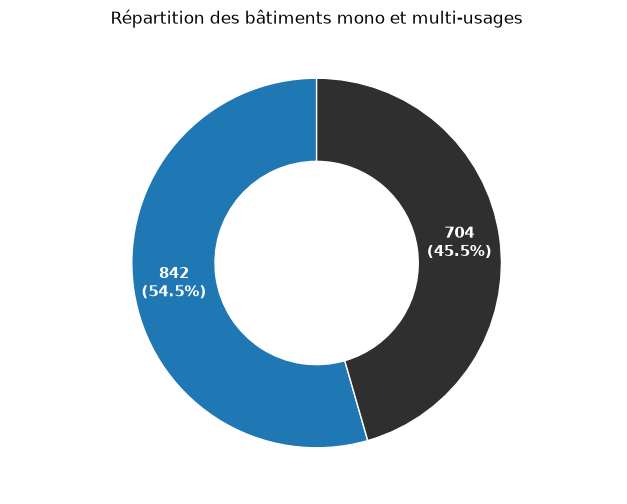

In [27]:
# Visualisation de la répartition des bâtiments mono et multi-usages

usage_counts = df_building_consumption["usage_type"].value_counts()

def autopct_format(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100))
        return f"{count}\n({pct:.1f}%)"
    return inner

plt.figure(figsize=(6, 6))

plt.pie(
    usage_counts,
    labels=usage_counts.index,
    colors=["#1f77b4", "#2f2f2f"],
    startangle=90,
    autopct=autopct_format(usage_counts),
    pctdistance=0.78,              # <- aproxima os números do centro
    labeldistance=1.08,            # <- mantém os rótulos um pouco para fora
    wedgeprops=dict(width=0.45, edgecolor="white"),
    textprops=dict(color="white", fontsize=11, fontweight="bold")
)

plt.title("Répartition des bâtiments mono et multi-usages")

plt.show()

> - La répartition des bâtiments est pratiquement équilibrée entre les catégories **mono-usage** et **multi-usages**, ce qui permet une comparaison pertinente.

##### **Consommation énergétique selon le type d'usage**

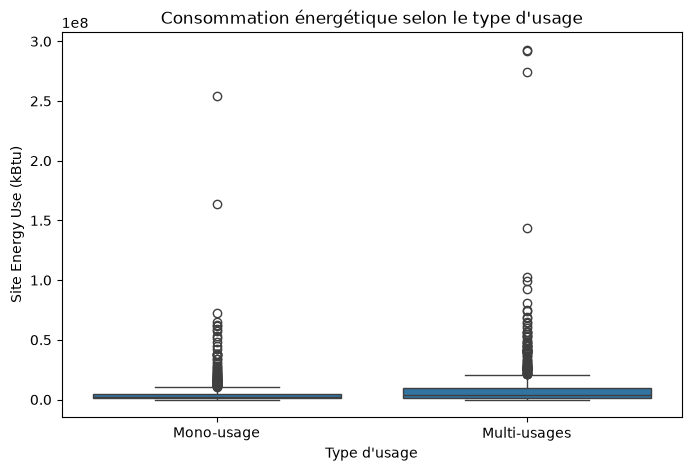

In [28]:
# Visualisation de la consommation énergétique selon le type d'usage

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_building_consumption,
    x="usage_type",
    y="SiteEnergyUse(kBtu)"
)

plt.title("Consommation énergétique selon le type d'usage")
plt.xlabel("Type d'usage")
plt.ylabel("Site Energy Use (kBtu)")

plt.show()

> - Le boxplot met en évidence la présence de nombreuses valeurs aberrantes dans les deux catégories. 
> - Ces bâtiments présentent une consommation énergétique exceptionnellement élevée, ce qui écrase la distribution et rend difficile la comparaison des valeurs centrales entre les bâtiments mono-usage et multi-usages.


##### **Tableau comparatif des bâtiments mono et multi-usages**

In [29]:
# Tableau comparatif des bâtiments mono et multi-usages (médianes)

comparison_table = (
    df_building_consumption
    .groupby("usage_type")[
        [
            "PropertyGFATotal",
            "NumberofFloors",
            "SiteEnergyUse(kBtu)"
        ]
    ]
    .median()
    .T
)

comparison_table.columns = ["Mono-usage", "Multi-usages"]

comparison_table.index = [
    "Property GFA Total",
    "Number of Floors",
    "Site Energy Use (kBtu)"
]

# Ajout de la colonne d'interprétation
comparison_table["Interprétation"] = [
    "Les bâtiments multi-usages présentent une surface médiane plus importante.",
    "Les bâtiments multi-usages comptent davantage d'étages.",
    "Les bâtiments multi-usages consomment davantage d'énergie."
]

# Transformation de l'index en colonne
comparison_table = (
    comparison_table
    .reset_index()
    .rename(columns={"index": "Variable"})
)

# Affichage
comparison_table.style \
    .format({
        "Mono-usage": "{:,.0f}",
        "Multi-usages": "{:,.0f}"
    }) \
    .set_properties(
        subset=["Variable", "Mono-usage", "Multi-usages"],
        **{"text-align": "center"}
    ) \
    .set_properties(
        subset=["Interprétation"],
        **{"text-align": "left"}
    ) \
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        }
    ])


,Variable,Mono-usage,Multi-usages,Interprétation
0,Property GFA Total,"40,498","56,942",Les bâtiments multi-usages présentent une surface médiane plus importante.
1,Number of Floors,2,3,Les bâtiments multi-usages comptent davantage d'étages.
2,Site Energy Use (kBtu),"1,926,402","3,541,467",Les bâtiments multi-usages consomment davantage d'énergie.


> - Les bâtiments **multi-usages** présentent une surface médiane plus importante, un nombre d'étages plus élevé ainsi qu'une consommation énergétique et des émissions de GES supérieures à celles des bâtiments **mono-usage**.

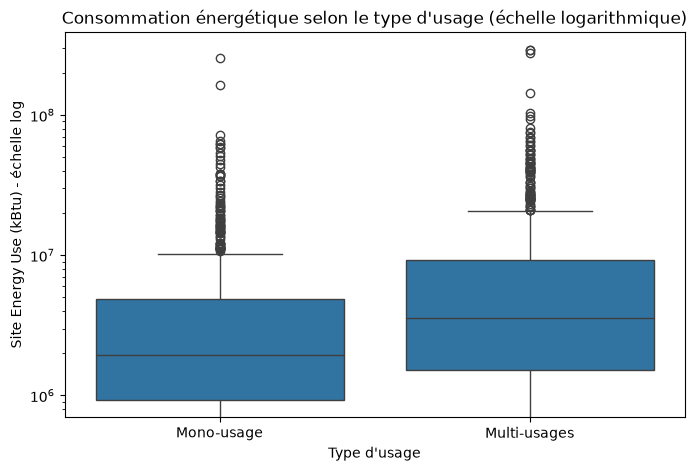

In [30]:
# Visualisation de la consommation énergétique selon le type d'usage (échelle logarithmique)

plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=df_building_consumption,
    x="usage_type",
    y="SiteEnergyUse(kBtu)"
)

ax.set_yscale("log")

plt.title("Consommation énergétique selon le type d'usage (échelle logarithmique)")
plt.xlabel("Type d'usage")
plt.ylabel("Site Energy Use (kBtu) - échelle log")

plt.show()

> - Les bâtiments à usage multiple ont tendance à consommer plus d'énergie et présentent une plus grande variabilité de consommation que les bâtiments à usage unique.

##### **Description des variables principales**

In [31]:
# Tableau récapitulatif des principales variables utilisées dans le projet

variables_summary = pd.DataFrame({
    "Variable": [
        "SiteEnergyUse(kBtu)",
        "PropertyGFATotal",
        "PrimaryPropertyType",
        "BuildingType",
        "YearBuilt",
        "NumberofFloors",
        "Neighborhood",
        "ENERGYSTARScore",
        "TotalGHGEmissions",
        "GHGEmissionsIntensity"
    ],

    "Description": [
        "Consommation énergétique totale annuelle du bâtiment",
        "Surface totale du bâtiment (Gross Floor Area)",
        "Type principal du bâtiment",
        "Classification du bâtiment (mono ou multi-usages)",
        "Année de construction",
        "Nombre d'étages",
        "Quartier où se situe le bâtiment",
        "Score de performance énergétique",
        "Émissions totales de gaz à effet de serre",
        "Intensité des émissions de gaz à effet de serre"
    ],

    "Utilisation": [
        "Variable cible",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Cible alternative",
        "Variable d'analyse"
    ]
})

# Affichage avec en-têtes centrés
variables_summary.style.set_table_styles([
    {
        "selector": "th",
        "props": [
            ("text-align", "center"),
            ("font-weight", "bold")
        ]
    }
]).set_properties(**{
    "text-align": "left"
})

,Variable,Description,Utilisation
0,SiteEnergyUse(kBtu),Consommation énergétique totale annuelle du bâtiment,Variable cible
1,PropertyGFATotal,Surface totale du bâtiment (Gross Floor Area),Feature
2,PrimaryPropertyType,Type principal du bâtiment,Feature
3,BuildingType,Classification du bâtiment (mono ou multi-usages),Feature
4,YearBuilt,Année de construction,Feature
5,NumberofFloors,Nombre d'étages,Feature
6,Neighborhood,Quartier où se situe le bâtiment,Feature
7,ENERGYSTARScore,Score de performance énergétique,Feature
8,TotalGHGEmissions,Émissions totales de gaz à effet de serre,Cible alternative
9,GHGEmissionsIntensity,Intensité des émissions de gaz à effet de serre,Variable d'analyse


#### **Analyse des outliers**

> - Les variables les plus importantes pour la modélisation sont analysées individuellement afin d'identifier d'éventuelles valeurs aberrantes susceptibles d'influencer les modèles.
> - Cette analyse permettra de déterminer, lors de l'étape de préparation des données, si un traitement spécifique des valeurs extrêmes est nécessaire.

##### **Analyse des outliers - SiteEnergyUse(kBtu)**

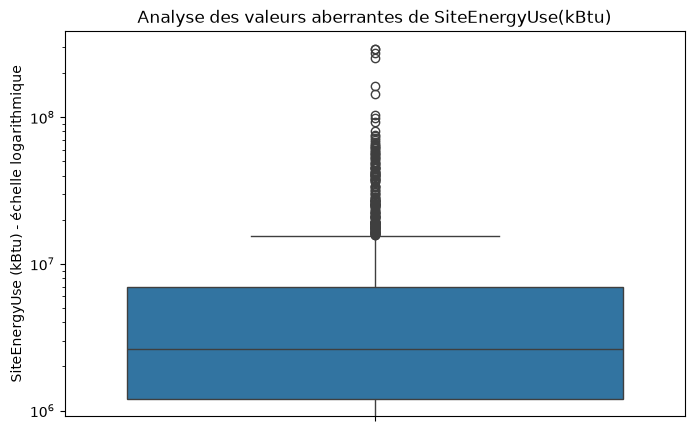

In [32]:
# Analyse des valeurs aberrantes - SiteEnergyUse(kBtu)

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_building_consumption,
    y="SiteEnergyUse(kBtu)"
)

# Échelle logarithmique pour améliorer la lisibilité
ax.set_yscale("log")

plt.title("Analyse des valeurs aberrantes de SiteEnergyUse(kBtu)")
plt.ylabel("SiteEnergyUse (kBtu) - échelle logarithmique")

plt.show()


> - Le boxplot met en évidence la présence de nombreux **outliers** pour la variable **SiteEnergyUse(kBtu)**.
> - L'échelle logarithmique améliore la visualisation de la distribution tout en conservant les valeurs extrêmes.
> -  Ces observations seront réévaluées lors de l'étape de préparation des données afin de déterminer si elles doivent être conservées ou traitées.

##### **Analyse des outliers - PropertyGFATotal**

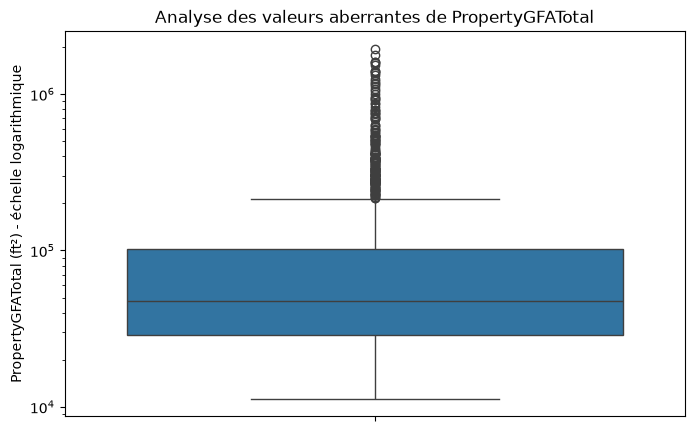

In [33]:
# Analyse des valeurs aberrantes - PropertyGFATotal

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_building_consumption,
    y="PropertyGFATotal"
)

# Échelle logarithmique pour améliorer la lisibilité
ax.set_yscale("log")

plt.title("Analyse des valeurs aberrantes de PropertyGFATotal")
plt.ylabel("PropertyGFATotal (ft²) - échelle logarithmique")

plt.show()


> - Le boxplot met en évidence la présence de nombreux outliers pour la variable **PropertyGFATotal**.
> - L'échelle logarithmique améliore la visualisation de la distribution tout en conservant les bâtiments de très grande superficie.
> - Ces observations seront analysées lors de la préparation des données afin de déterminer si elles doivent être conservées ou traitées.

##### **Analyse des outliers - NumberofFloors**

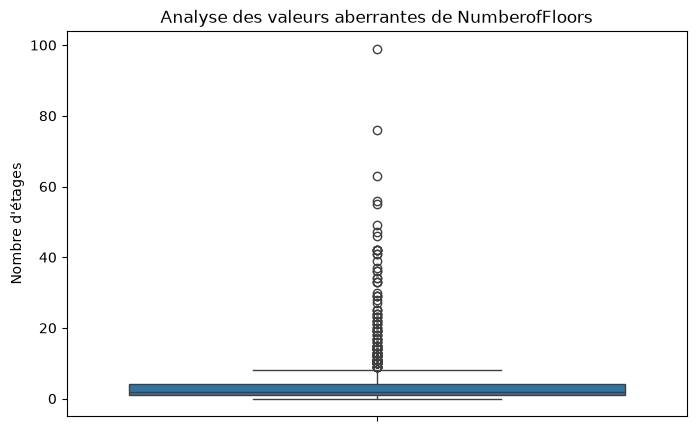

In [34]:
# Analyse des valeurs aberrantes - NumberofFloors

plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df_building_consumption,
    y="NumberofFloors"
)

plt.title("Analyse des valeurs aberrantes de NumberofFloors")
plt.ylabel("Nombre d'étages")

plt.show()

> - Le boxplot met en évidence la présence de plusieurs outliers pour la variable **NumberofFloors**, correspondant à des bâtiments exceptionnellement élevés.
> - La majorité des bâtiments possède un nombre d'étages relativement faible, tandis que quelques observations présentent des valeurs nettement supérieures.
> - Ces observations seront examinées lors de la préparation des données afin de vérifier leur cohérence et leur impact sur la modélisation.

#### **Identification des bâtiments incohérents**

Avant de préparer les données pour la modélisation, il est nécessaire d'identifier les bâtiments présentant des valeurs incohérentes.

In [35]:
# Suppression des bâtiments présentant des valeurs incohérentes

rows_before = len(df_building_consumption)

df_building_consumption = df_building_consumption[
    (df_building_consumption["PropertyGFATotal"] > 0) &
    (df_building_consumption["SiteEnergyUse(kBtu)"] > 0) &
    (df_building_consumption["NumberofFloors"] >= 0) &
    (df_building_consumption["YearBuilt"] <= 2016)
].copy()

rows_after = len(df_building_consumption)

print(f"Nombre de lignes avant nettoyage : {rows_before}")
print(f"Nombre de lignes après nettoyage : {rows_after}")
print(f"Nombre de bâtiments supprimés : {rows_before - rows_after}")

Nombre de lignes avant nettoyage : 1546
Nombre de lignes après nettoyage : 1542
Nombre de bâtiments supprimés : 4


> - 4 bâtiments présentant des valeurs incohérentes ont été supprimés.
> - Les bâtiments avec une consommation énergétique égale à zéro malgré une surface renseignée, ainsi que les bâtiments avec des émissions de GES négatives, ont été considérés comme des données incohérentes et supprimés.
> - Le jeu de données nettoyé contient désormais **1542 bâtiments**, prêts pour la phase de modélisation.

#### **Analyse des variables**

##### **Surface du bâtiment** (Quanti vs quanti)

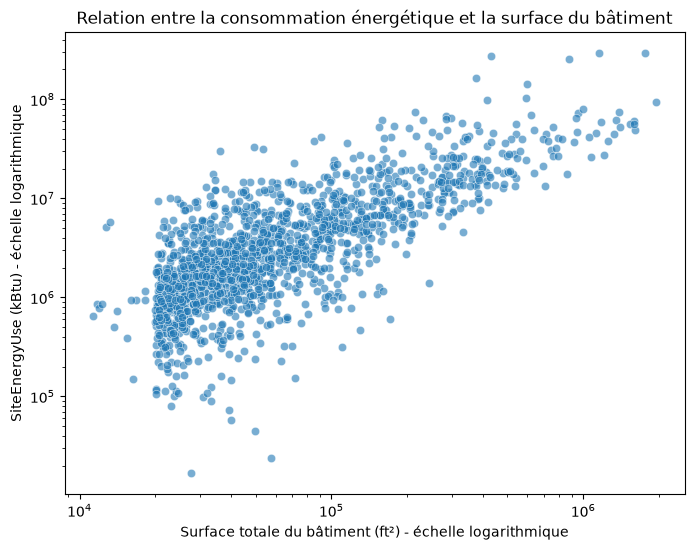

In [36]:
# Relation entre la surface totale du bâtiment et la consommation énergétique

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_building_consumption,
    x="PropertyGFATotal",
    y="SiteEnergyUse(kBtu)",
    alpha=0.6
)

# Échelle logarithmique
plt.xscale("log")
plt.yscale("log")

plt.title("Relation entre la consommation énergétique et la surface du bâtiment")
plt.xlabel("Surface totale du bâtiment (ft²) - échelle logarithmique")
plt.ylabel("SiteEnergyUse (kBtu) - échelle logarithmique")

plt.show()

> - Une corrélation positive est observée entre la surface totale du bâtiment et la consommation énergétique.
> - Les bâtiments de plus grande superficie ont généralement une consommation énergétique plus élevée.
> - PropertyGFATotal apparaît comme l'une des variables explicatives les plus pertinentes pour la modélisation.

##### **Année de construction** (Quanti vs quanti)

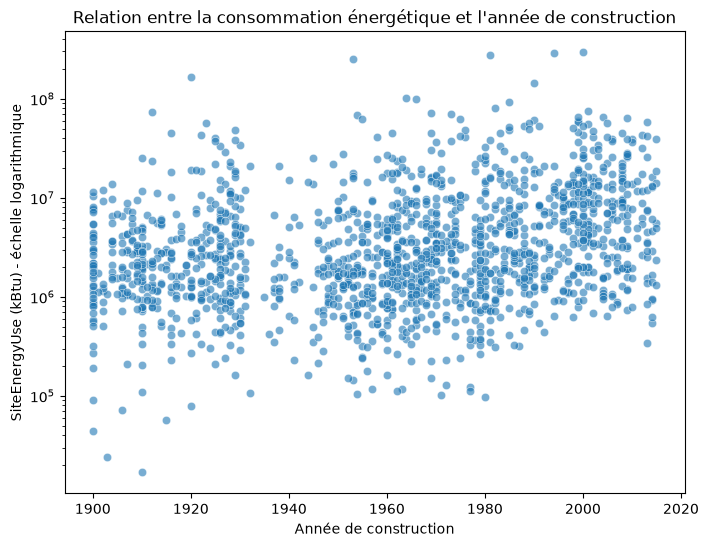

In [37]:
# Relation entre l'année de construction et la consommation énergétique

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_building_consumption,
    x="YearBuilt",
    y="SiteEnergyUse(kBtu)",
    alpha=0.6
)

# Échelle logarithmique uniquement pour la consommation énergétique
plt.yscale("log")

plt.title("Relation entre la consommation énergétique et l'année de construction")
plt.xlabel("Année de construction")
plt.ylabel("SiteEnergyUse (kBtu) - échelle logarithmique")

plt.show()


> - Aucune relation linéaire forte n'est observée entre l'année de construction et la consommation énergétique.
> - Les bâtiments récents ne présentent pas systématiquement une consommation énergétique plus faible.
> - YearBuilt pourrait avoir une influence plus limitée que PropertyGFATotal sur la consommation énergétique.

##### **Type principal du bâtiment** (Quanti vs quali)

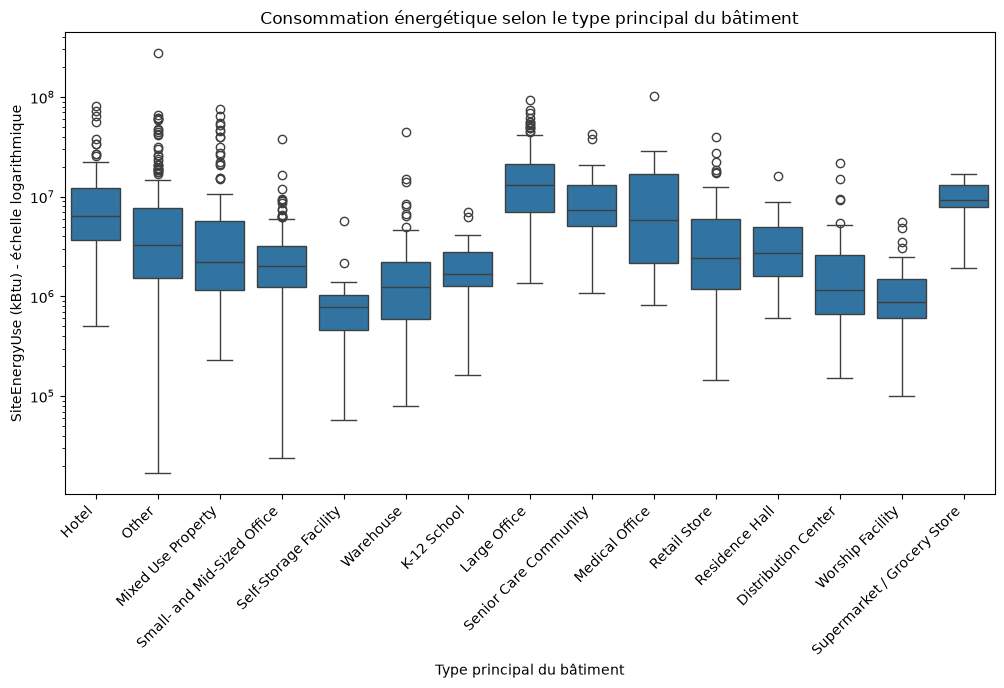

In [38]:
# Consommation énergétique selon le type principal du bâtiment

# Sélection des 15 types de bâtiments les plus fréquents
top15 = (
    df_building_consumption["PrimaryPropertyType"]
    .value_counts()
    .head(15)
    .index
)

df_top15 = df_building_consumption[
    df_building_consumption["PrimaryPropertyType"].isin(top15)
]

plt.figure(figsize=(12, 6))

ax = sns.boxplot(
    data=df_top15,
    x="PrimaryPropertyType",
    y="SiteEnergyUse(kBtu)"
)

ax.set_yscale("log")

plt.xticks(rotation=45, ha="right")

plt.title("Consommation énergétique selon le type principal du bâtiment")
plt.xlabel("Type principal du bâtiment")
plt.ylabel("SiteEnergyUse (kBtu) - échelle logarithmique")

plt.show()

> - La consommation énergétique varie selon le type principal du bâtiment.
> - Les Large Office, Supermarket / Grocery Store et Hotel présentent généralement les niveaux de consommation les plus élevés.
> - Le type principal du bâtiment apparaît comme une variable explicative pertinente pour la modélisation de la consommation énergétique.

##### **Matrice de corrélation des variables numériques**

La matrice suivante permet d'identifier les variables les plus liées à la consommation énergétique

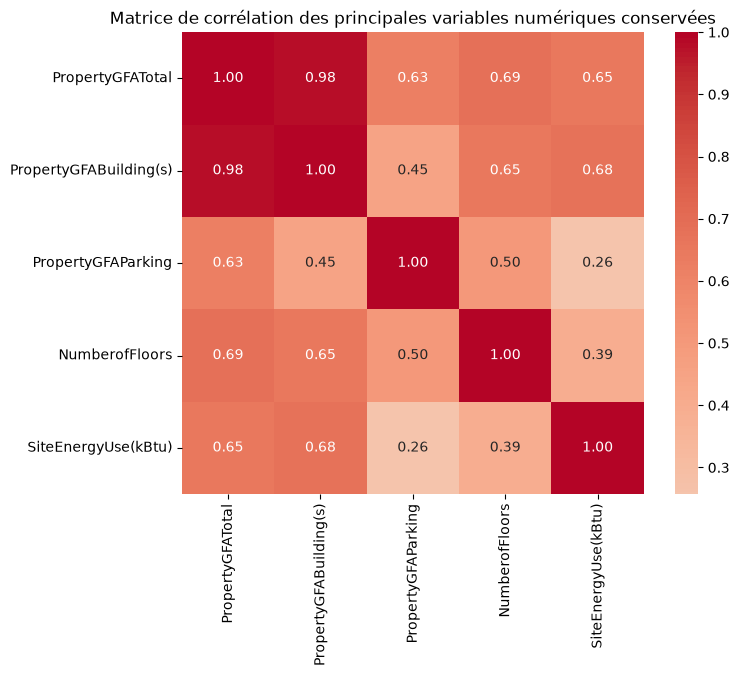

In [39]:
# Matrice de corrélation des principales variables numériques

correlation_columns = [
    "PropertyGFATotal",
    "PropertyGFABuilding(s)",
    "PropertyGFAParking",
    "NumberofFloors",
    "SiteEnergyUse(kBtu)"
]

corr = df_building_consumption[correlation_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True
)

plt.title("Matrice de corrélation des principales variables numériques conservées")
plt.show()

> - La matrice de corrélation met en évidence une très forte corrélation entre **PropertyGFATotal (0,98)** et **PropertyGFABuilding(s)**. 
> - La variable PropertyGFATotal sera supprimée dans la prochaine analyse de correlation.

#### **Conclusion**

> - La consommation énergétique est fortement liée à la superficie des bâtiments.
> - Les bâtiments multi-usages présentent généralement une consommation plus élevée.
> - Les caractéristiques physiques des bâtiments apparaissent comme les variables les plus explicatives de la consommation énergétique.
> - Les variables identifiées comme sources de *Data Leakage* ont été supprimées dès le début de l'analyse afin de garantir une démarche méthodologique rigoureuse.
> - Les vérifications réalisées n'ont mis en évidence aucune incohérence supplémentaire dans les données conservées.

Les observations réalisées permettront d'orienter les choix de préparation des données lors de l'étape de **Feature Engineering**.

In [40]:
# Dimensions finales du jeu de données

print(f"Nombre de lignes : {df_building_consumption.shape[0]}")
print(f"Nombre de colonnes : {df_building_consumption.shape[1]}")

Nombre de lignes : 1542
Nombre de colonnes : 32


> - Après le nettoyage, le jeu de données contient **1542 bâtiments** et **32 colonnes**.
> - Ce jeu de données est désormais prêt pour la phase de **Feature Engineering** et de modélisation.

### **Sauvegarde du jeu de données nettoyé**

In [41]:
from pathlib import Path

# Création du dossier
Path("../data/processed").mkdir(parents=True, exist_ok=True)

# Sauvegarde du jeu de données
df_building_consumption.to_csv(
    "../data/processed/buildings_clean.csv",
    index=False
)

print("Jeu de données sauvegardé avec succès.")
print(Path("../data/processed/buildings_clean.csv").resolve())

Jeu de données sauvegardé avec succès.
C:\Users\FR103217\OneDrive - MOTUL\Bureau\data_scientist\project_3\data\processed\buildings_clean.csv
